In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import requests
import mplfinance as mpf
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from lightweight_charts import Chart

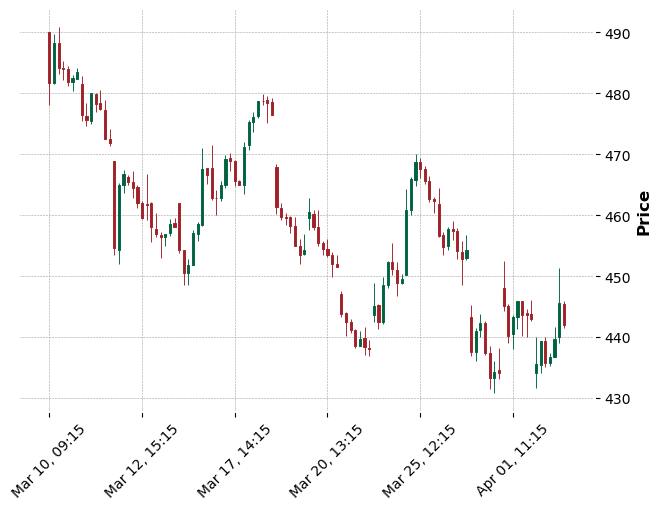

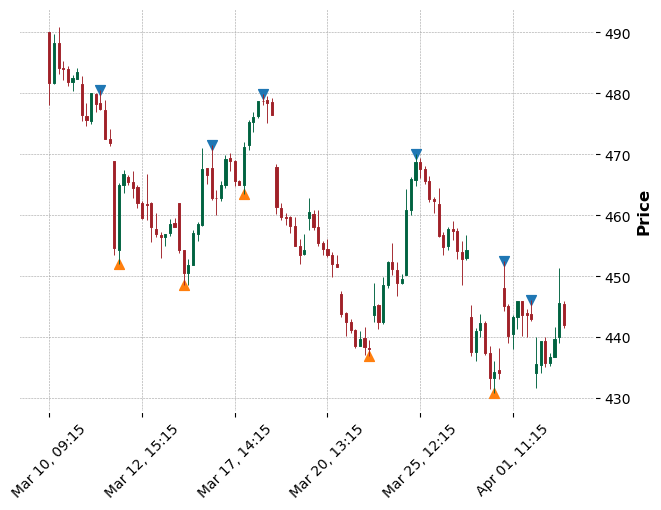

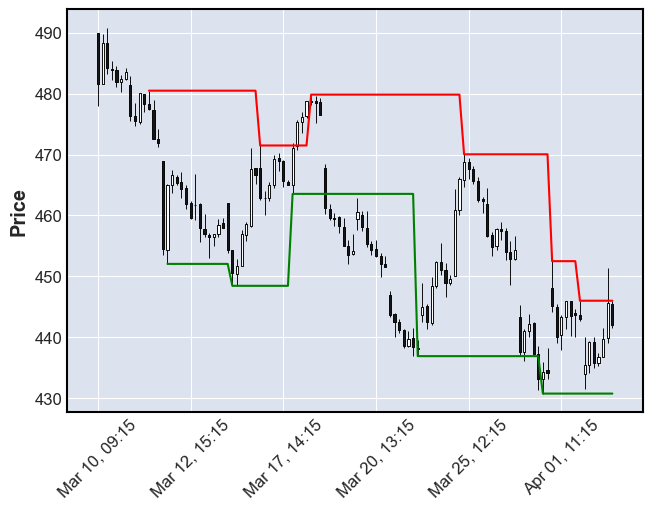

                                 Open        High         Low       Close  \
Datetime                                                                    
2026-03-10 09:15:00+05:30  490.000000  490.000000  478.049988  481.649994   
2026-03-10 10:15:00+05:30  481.649994  489.799988  481.549988  488.299988   
2026-03-10 11:15:00+05:30  488.299988  490.850006  483.200012  484.250000   
2026-03-10 12:15:00+05:30  484.100006  485.299988  482.200012  483.950012   
2026-03-10 13:15:00+05:30  483.950012  484.549988  481.149994  481.899994   
...                               ...         ...         ...         ...   
2026-04-02 11:15:00+05:30  439.250000  440.000000  435.000000  435.700012   
2026-04-02 12:15:00+05:30  435.700012  437.350006  435.299988  436.700012   
2026-04-02 13:15:00+05:30  436.700012  441.600006  436.700012  439.700012   
2026-04-02 14:15:00+05:30  439.950012  451.399994  439.000000  445.649994   
2026-04-02 15:15:00+05:30  445.450012  445.899994  441.450012  442.000000   

In [19]:
#Sweep Strength Code - Static

#Swings detector 
Ticker = 'JUBLFOOD.NS'

def telegram_alert(message):
        url = f'https://api.telegram.org/bot8520982329:AAGr_PfQPzUFI2zQDWJ41TAtmCobla2JcZY/sendMessage'
        Data = {'chat_id': '-5245957606',
        'text': message
        }
        requests.post(url,data=Data) 

position = -40
period = round(((1/7)*-position)+10)

BTC = yf.Ticker(Ticker).history(period=f'{period}d', interval='1h' )
if BTC.empty:
     print(f'No data found for {Ticker}')

conditions_swing = [
       (BTC['High']>BTC['High'].shift(-1))&(BTC['High']>BTC['High'].shift(1)),
       (BTC['Low']<BTC['Low'].shift(-1))&(BTC['Low']<BTC['Low'].shift(1))
]

labels_swing = ["Swing High","Swing Low"]


BTC['Master_Swing'] = np.select(conditions_swing,labels_swing,default="")

BTC["Candle No."] = range(len(BTC),0,-1)

Subset_df = BTC[BTC['Master_Swing'] !=''].copy()

conditions_slope = [
       (Subset_df['Master_Swing']=="Swing Low") & 
       (Subset_df['Master_Swing'].shift(1)=="Swing High"), 
       (Subset_df['Master_Swing']=="Swing High") & 
       (Subset_df['Master_Swing'].shift(1)=="Swing Low")
]

labels_slope = ["Sell Slope","Buy Slope"]

Subset_df["Slope"] = np.select(conditions_slope,labels_slope,'')

conditions_Delta = [
       (Subset_df["Slope"] == "Sell Slope"),
       (Subset_df["Slope"] == "Buy Slope")
]

labels_Delta = [
       (Subset_df["High"].shift(1)-Subset_df["Low"])/
       (Subset_df["Candle No."].shift(1) - Subset_df["Candle No."]),
       (Subset_df["High"]-Subset_df["Low"]).shift(1)/
       (Subset_df["Candle No."].shift(1) - Subset_df["Candle No."])                             
]

Subset_df["Price Delta"] = np.select(conditions_Delta,labels_Delta,np.nan)


BTC.loc[Subset_df.index,"Slope"] = Subset_df["Slope"]
BTC.loc[Subset_df.index,"Price Delta"] = Subset_df["Price Delta"]
#ATR calculation

ATR_value = 7

BTC['H-L'] = (BTC["High"] - BTC["Low"])
BTC['H-C'] = (BTC["High"] - BTC["Close"].shift(1))
BTC['L-C'] = (BTC["Low"] - BTC["Close"].shift(1))

BTC["TR"] = BTC[['H-L','H-C','L-C']].max(axis=1)
BTC["ATR"] = BTC["TR"].rolling(ATR_value).mean()

Subset_ATR = BTC[BTC['Master_Swing'] !=''].copy()

Subset_ATR["Impluse Strength"] = Subset_ATR["Price Delta"]/(Subset_ATR["ATR"].shift(1))
BTC.loc[Subset_ATR.index,"Impluse Strength"] = Subset_ATR["Impluse Strength"]

#Intermediate Swings - To be used for BOS and Breaker   
swing_lows = Subset_df.loc[Subset_df["Master_Swing"]=="Swing Low", ["Low"]]
swing_highs = Subset_df.loc[Subset_df["Master_Swing"]=="Swing High", ["High"]]

conditions_Intermediate = [
       (swing_lows["Low"] < swing_lows["Low"].shift(1)) &
       (swing_lows["Low"] < swing_lows["Low"].shift(-1)),
]
labels_Intermediate_Low = ["Intermediate Swing Low"]

swing_lows["Intermediate_Swing_Low"] = np.select(conditions_Intermediate,labels_Intermediate_Low,'')

conditions_Intermediate_High = [
       (swing_highs["High"] > swing_highs["High"].shift(1)) &
       (swing_highs["High"] > swing_highs["High"].shift(-1))
]

labels_Intermediate_High = ["Intermediate Swing High"]

swing_highs["Intermediate_Swing_High"] = np.select(conditions_Intermediate_High,labels_Intermediate_High,'')    

BTC.loc[swing_lows.index,"Intermediate_Swing"] = swing_lows["Intermediate_Swing_Low"]
BTC.loc[swing_lows.index,"ISL_Price"] = np.where(swing_lows["Intermediate_Swing_Low"]=="Intermediate Swing Low",swing_lows["Low"],np.nan)
BTC.loc[swing_highs.index,"Intermediate_Swing"] = swing_highs["Intermediate_Swing_High"]
BTC.loc[swing_highs.index,"ISH_Price"] = np.where(swing_highs["Intermediate_Swing_High"]=="Intermediate Swing High",swing_highs["High"],np.nan)

#Intermediate support and resistance levels

BTC["ISH_Price_Ffill"] = BTC["ISH_Price"].ffill()
BTC["ISL_Price_Ffill"] = BTC["ISL_Price"].ffill()

#Breaker Signal

Subset_Breaker = BTC[BTC['Master_Swing'] !=''].copy()

Subset_Breaker['Breaker_Signal'] = (
        (Subset_Breaker['Master_Swing'] == 'Swing High')&
        (Subset_Breaker['Master_Swing'].shift(1)=='Swing Low')&
        (Subset_Breaker['Master_Swing'].shift(2)=='Swing High')&
        (Subset_Breaker['Master_Swing'].shift(3)=='Swing Low')&
        (Subset_Breaker['High']>Subset_Breaker['High'].shift(2))&
        (Subset_Breaker['Low'].shift(1)<Subset_Breaker['Low'].shift(3))
        )

BTC.loc[Subset_Breaker.index,"Breaker_Signal"] = Subset_Breaker["Breaker_Signal"]

#BOS Signal

lookback = 3
Subset_df["Rolling_SL_Min"] = swing_lows["Low"].shift(1).rolling(window=lookback).min()
Subset_df["Rolling_SH_Max"] = swing_highs["High"].shift(1).rolling(window=lookback).max()

Subset_df["Bearish BOS"] = np.where((Subset_df["Master_Swing"] == "Swing Low")&
              (Subset_df["Low"] < Subset_df["Rolling_SL_Min"]),
              True, 
              False
)

Subset_df["Bullish BOS"] = np.where((Subset_df["Master_Swing"] == "Swing High")&
              (Subset_df["High"] > Subset_df["Rolling_SH_Max"]),
              True, 
              False
)

BTC.loc[Subset_df.index,"Bearish BOS"] = Subset_df["Bearish BOS"]
BTC.loc[Subset_df.index,"Bullish BOS"] = Subset_df["Bullish BOS"]
#Liquity sweep Signal (IS Level Break) (Eary warning signal for Breaker)

BTC["ISL Sweep"] = np.where((BTC["Close"].shift(1) > BTC["ISL_Price_Ffill"].shift(1)) & (BTC["Low"] < BTC["ISL_Price_Ffill"].shift(1)), True, False)
BTC["ISH Sweep"] = np.where((BTC["Close"].shift(1) < BTC["ISH_Price_Ffill"].shift(1)) & (BTC["High"] > BTC["ISH_Price_Ffill"].shift(1)), True, False)
BTC["ISL Sweep Strength"] = np.where(BTC["ISL Sweep"] == True, (BTC["High"] - BTC["Low"])/BTC["ATR"], np.nan)
BTC["ISH Sweep Strength"] = np.where(BTC["ISH Sweep"] == True, (BTC["High"] - BTC["Low"])/BTC["ATR"], np.nan)

#Liqiuidity Sweep with BOS confluence
BTC["ISL_Sweep+BOS"] = np.where((BTC["Bearish BOS"] == True) & (BTC["Low"] < BTC["ISL_Price_Ffill"].shift(1)), True, False)
BTC["ISH_Sweep+BOS"] = np.where((BTC["Bullish BOS"] == True) & (BTC["High"] > BTC["ISH_Price_Ffill"].shift(1)), True, False)

#FVG

BTC["FVG_Bullish"] = (BTC["Low"].shift(-1)>BTC["High"].shift(1))
BTC["FVG_Bearish"] = (BTC["High"].shift(-1)<BTC["Low"].shift(1))

#FVG Strength

BTC["FVG_Bullish_Strength"] = np.where(BTC["FVG_Bullish"]==True, (BTC["High"]-BTC["Low"])/BTC["ATR"], np.nan)
BTC["FVG_Bearish_Strength"] = np.where(BTC["FVG_Bearish"]==True, (BTC["High"]-BTC["Low"])/BTC["ATR"], np.nan)

# Sending Alerts to Telegram


if BTC["ISL_Sweep+BOS"].iloc[position] == True:
       alert_time = BTC.index[position]
       alert_message = f"ISL_Sweep+BOS for {Ticker} @ {alert_time}"
       telegram_alert(alert_message)

# Swing Lows within .5% of an Intermediate Swing Low (Potential Liquidity Zone)

BTC["Swing_Low_value"] = np.where(BTC["Master_Swing"]=="Swing Low", BTC["Low"], np.nan)

BTC["Proximity_to_ISL"] = np.where(
    (BTC["Swing_Low_value"] > BTC["ISL_Price_Ffill"]) & 
    (BTC["Swing_Low_value"] <= 1.0025 * BTC["ISL_Price_Ffill"]),
    True,
    False
)

#Plotting Data 

mpf.plot(
    BTC,
    type='candle',
    style='charles',
    volume=False
)



mpf.plot(
    BTC,
    type='candle',
    style='charles',
    addplot=[
        mpf.make_addplot(
            BTC["ISH_Price"],
            type='scatter',
            markersize=50,
            marker='v'
        ),
        mpf.make_addplot(
            BTC["ISL_Price"],
            type='scatter',
            markersize=50,
            marker='^'
        )
    ]
)


apds = [
    mpf.make_addplot(BTC["ISH_Price_Ffill"], color='red'),
    mpf.make_addplot(BTC["ISL_Price_Ffill"], color='green')
]

mpf.plot(
    BTC,
    type='candle',
    addplot=apds
)

print(BTC)
BTC.to_csv("SUP12345.csv")


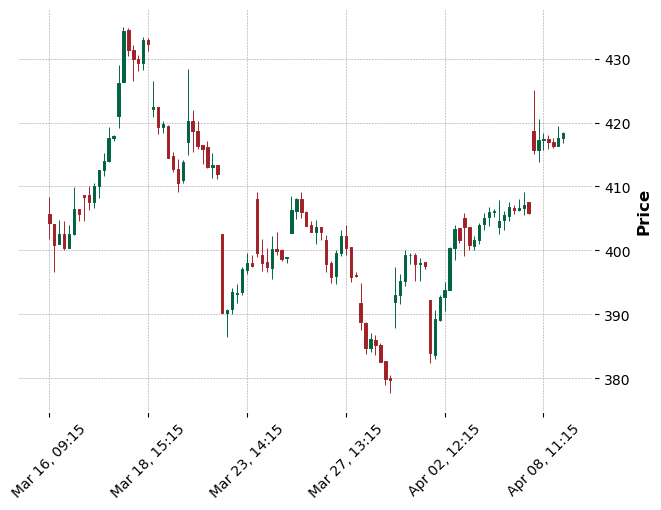

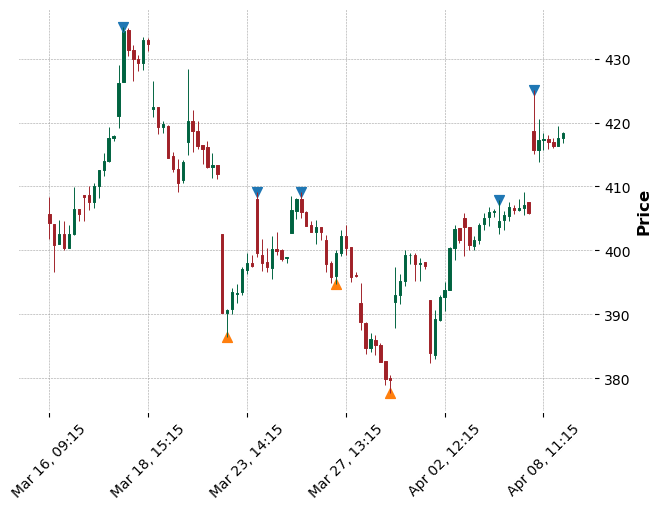

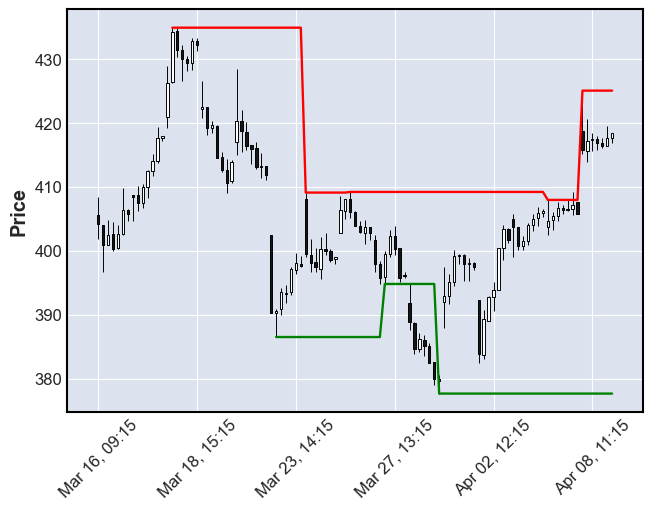

                                 Open        High         Low       Close  \
Datetime                                                                    
2026-03-16 09:15:00+05:30  405.649994  408.399994  401.850006  404.250000   
2026-03-16 10:15:00+05:30  404.049988  404.049988  396.600006  400.850006   
2026-03-16 11:15:00+05:30  400.950012  404.799988  400.950012  402.500000   
2026-03-16 12:15:00+05:30  402.600006  404.549988  400.000000  400.299988   
2026-03-16 13:15:00+05:30  400.350006  404.000000  400.299988  402.600006   
...                               ...         ...         ...         ...   
2026-04-08 11:15:00+05:30  417.250000  418.399994  415.649994  417.500000   
2026-04-08 12:15:00+05:30  417.500000  418.000000  415.799988  416.899994   
2026-04-08 13:15:00+05:30  416.899994  417.649994  416.049988  416.350006   
2026-04-08 14:15:00+05:30  416.399994  419.450012  416.350006  417.649994   
2026-04-08 15:15:00+05:30  417.600006  418.450012  416.799988  418.399994   

In [14]:
#This version is for testing for a specific time period start and end dates can be defined in the yf.Ticker().history() function. The position variable can be adjusted to check for signals at different points in time.
#the yfinance code is as follows for reference for the above code block
# yf.Ticker(Ticker).history(period='20d', interval='1h' )
#the end date can also be defined using the end parameter in the history function and the 
# position variable can be adjusted accordingly to check for signals at different points in time. 
# For example, if the end date is set to '2024-06-01' and the position variable is set to -10, it will check for signals 10 hours before the end date.
#so the code block for fetching data using yfinance would be as follows:
#the end_date = '2024-06-01' which goeses in the yf.Ticker().history() function as end=end_date and the position variable can be set to -10 to check for signals 10 hours before the end date.
#the code block for fetching data using yfinance with a specific end date and position variable would be as follows:
#yf.Ticker(Ticker).history(end='2024-06-01', interval='1h' )
#Alternatively we can use a start date and end date to fetch data for a specific time period. For example, 
# if we want to fetch data from '2024-05-01' to '2024-06-01', we can use the following code block:


#Sweep Strength Code - Static

#Swings detector 
Ticker = 'PFC.NS'

def telegram_alert(message):
        url = f'https://api.telegram.org/bot8520982329:AAGr_PfQPzUFI2zQDWJ41TAtmCobla2JcZY/sendMessage'
        Data = {'chat_id': '-5245957606',
        'text': message
        }
        requests.post(url,data=Data) 

position = -10
period = round(((1/7)*-position)+10)

BTC = yf.Ticker(Ticker).history(start='2026-03-15', end='2026-04-09', interval='1h' )
if BTC.empty:
     print(f'No data found for {Ticker}')

conditions_swing = [
       (BTC['High']>BTC['High'].shift(-1))&(BTC['High']>BTC['High'].shift(1)),
       (BTC['Low']<BTC['Low'].shift(-1))&(BTC['Low']<BTC['Low'].shift(1))
]

labels_swing = ["Swing High","Swing Low"]


BTC['Master_Swing'] = np.select(conditions_swing,labels_swing,default="")

BTC["Candle No."] = range(len(BTC),0,-1)

Subset_df = BTC[BTC['Master_Swing'] !=''].copy()

conditions_slope = [
       (Subset_df['Master_Swing']=="Swing Low") & 
       (Subset_df['Master_Swing'].shift(1)=="Swing High"), 
       (Subset_df['Master_Swing']=="Swing High") & 
       (Subset_df['Master_Swing'].shift(1)=="Swing Low")
]

labels_slope = ["Sell Slope","Buy Slope"]

Subset_df["Slope"] = np.select(conditions_slope,labels_slope,'')

conditions_Delta = [
       (Subset_df["Slope"] == "Sell Slope"),
       (Subset_df["Slope"] == "Buy Slope")
]

labels_Delta = [
       (Subset_df["High"].shift(1)-Subset_df["Low"])/
       (Subset_df["Candle No."].shift(1) - Subset_df["Candle No."]),
       (Subset_df["High"]-Subset_df["Low"]).shift(1)/
       (Subset_df["Candle No."].shift(1) - Subset_df["Candle No."])                             
]

Subset_df["Price Delta"] = np.select(conditions_Delta,labels_Delta,np.nan)


BTC.loc[Subset_df.index,"Slope"] = Subset_df["Slope"]
BTC.loc[Subset_df.index,"Price Delta"] = Subset_df["Price Delta"]
#ATR calculation

ATR_value = 7

BTC['H-L'] = (BTC["High"] - BTC["Low"])
BTC['H-C'] = (BTC["High"] - BTC["Close"].shift(1))
BTC['L-C'] = (BTC["Low"] - BTC["Close"].shift(1))

BTC["TR"] = BTC[['H-L','H-C','L-C']].max(axis=1)
BTC["ATR"] = BTC["TR"].rolling(ATR_value).mean()

Subset_ATR = BTC[BTC['Master_Swing'] !=''].copy()

Subset_ATR["Impluse Strength"] = Subset_ATR["Price Delta"]/(Subset_ATR["ATR"].shift(1))
BTC.loc[Subset_ATR.index,"Impluse Strength"] = Subset_ATR["Impluse Strength"]

#Intermediate Swings - To be used for BOS and Breaker   
swing_lows = Subset_df.loc[Subset_df["Master_Swing"]=="Swing Low", ["Low"]]
swing_highs = Subset_df.loc[Subset_df["Master_Swing"]=="Swing High", ["High"]]

conditions_Intermediate = [
       (swing_lows["Low"] < swing_lows["Low"].shift(1)) &
       (swing_lows["Low"] < swing_lows["Low"].shift(-1)),
]
labels_Intermediate_Low = ["Intermediate Swing Low"]

swing_lows["Intermediate_Swing_Low"] = np.select(conditions_Intermediate,labels_Intermediate_Low,'')

conditions_Intermediate_High = [
       (swing_highs["High"] > swing_highs["High"].shift(1)) &
       (swing_highs["High"] > swing_highs["High"].shift(-1))
]

labels_Intermediate_High = ["Intermediate Swing High"]

swing_highs["Intermediate_Swing_High"] = np.select(conditions_Intermediate_High,labels_Intermediate_High,'')    

BTC.loc[swing_lows.index,"Intermediate_Swing"] = swing_lows["Intermediate_Swing_Low"]
BTC.loc[swing_lows.index,"ISL_Price"] = np.where(swing_lows["Intermediate_Swing_Low"]=="Intermediate Swing Low",swing_lows["Low"],np.nan)
BTC.loc[swing_highs.index,"Intermediate_Swing"] = swing_highs["Intermediate_Swing_High"]
BTC.loc[swing_highs.index,"ISH_Price"] = np.where(swing_highs["Intermediate_Swing_High"]=="Intermediate Swing High",swing_highs["High"],np.nan)

#Intermediate support and resistance levels

BTC["ISH_Price_Ffill"] = BTC["ISH_Price"].ffill()
BTC["ISL_Price_Ffill"] = BTC["ISL_Price"].ffill()

#Breaker Signal

Subset_Breaker = BTC[BTC['Master_Swing'] !=''].copy()

Subset_Breaker['Breaker_Signal'] = (
        (Subset_Breaker['Master_Swing'] == 'Swing High')&
        (Subset_Breaker['Master_Swing'].shift(1)=='Swing Low')&
        (Subset_Breaker['Master_Swing'].shift(2)=='Swing High')&
        (Subset_Breaker['Master_Swing'].shift(3)=='Swing Low')&
        (Subset_Breaker['High']>Subset_Breaker['High'].shift(2))&
        (Subset_Breaker['Low'].shift(1)<Subset_Breaker['Low'].shift(3))
        )

BTC.loc[Subset_Breaker.index,"Breaker_Signal"] = Subset_Breaker["Breaker_Signal"]

#BOS Signal

lookback = 3
Subset_df["Rolling_SL_Min"] = swing_lows["Low"].shift(1).rolling(window=lookback).min()
Subset_df["Rolling_SH_Max"] = swing_highs["High"].shift(1).rolling(window=lookback).max()

Subset_df["Bearish BOS"] = np.where((Subset_df["Master_Swing"] == "Swing Low")&
              (Subset_df["Low"] < Subset_df["Rolling_SL_Min"]),
              True, 
              False
)

Subset_df["Bullish BOS"] = np.where((Subset_df["Master_Swing"] == "Swing High")&
              (Subset_df["High"] > Subset_df["Rolling_SH_Max"]),
              True, 
              False
)

BTC.loc[Subset_df.index,"Bearish BOS"] = Subset_df["Bearish BOS"]
BTC.loc[Subset_df.index,"Bullish BOS"] = Subset_df["Bullish BOS"]
#Liquity sweep Signal (IS Level Break) (Eary warning signal for Breaker)

BTC["ISL Sweep"] = np.where((BTC["Close"].shift(1) > BTC["ISL_Price_Ffill"].shift(1)) & (BTC["Low"] < BTC["ISL_Price_Ffill"].shift(1)), True, False)
BTC["ISH Sweep"] = np.where((BTC["Close"].shift(1) < BTC["ISH_Price_Ffill"].shift(1)) & (BTC["High"] > BTC["ISH_Price_Ffill"].shift(1)), True, False)
BTC["ISL Sweep Strength"] = np.where(BTC["ISL Sweep"] == True, (BTC["High"] - BTC["Low"])/BTC["ATR"], np.nan)
BTC["ISH Sweep Strength"] = np.where(BTC["ISH Sweep"] == True, (BTC["High"] - BTC["Low"])/BTC["ATR"], np.nan)

#Liqiuidity Sweep with BOS confluence
BTC["ISL_Sweep+BOS"] = np.where((BTC["Bearish BOS"] == True) & (BTC["Low"] < BTC["ISL_Price_Ffill"].shift(1)), True, False)
BTC["ISH_Sweep+BOS"] = np.where((BTC["Bullish BOS"] == True) & (BTC["High"] > BTC["ISH_Price_Ffill"].shift(1)), True, False)

#FVG

BTC["FVG_Bullish"] = (BTC["Low"].shift(-1)>BTC["High"].shift(1))
BTC["FVG_Bearish"] = (BTC["High"].shift(-1)<BTC["Low"].shift(1))

#FVG Strength

BTC["FVG_Bullish_Strength"] = np.where(BTC["FVG_Bullish"]==True, (BTC["High"]-BTC["Low"])/BTC["ATR"], np.nan)
BTC["FVG_Bearish_Strength"] = np.where(BTC["FVG_Bearish"]==True, (BTC["High"]-BTC["Low"])/BTC["ATR"], np.nan)

# Sending Alerts to Telegram


if BTC["ISL_Sweep+BOS"].iloc[position] == True:
       alert_time = BTC.index[position]
       alert_message = f"ISL_Sweep+BOS for {Ticker} @ {alert_time}"
       telegram_alert(alert_message)


#Plotting Data 

mpf.plot(
    BTC,
    type='candle',
    style='charles',
    volume=False
)



mpf.plot(
    BTC,
    type='candle',
    style='charles',
    addplot=[
        mpf.make_addplot(
            BTC["ISH_Price"],
            type='scatter',
            markersize=50,
            marker='v'
        ),
        mpf.make_addplot(
            BTC["ISL_Price"],
            type='scatter',
            markersize=50,
            marker='^'
        )
    ]
)


apds = [
    mpf.make_addplot(BTC["ISH_Price_Ffill"], color='red'),
    mpf.make_addplot(BTC["ISL_Price_Ffill"], color='green')
]

mpf.plot(
    BTC,
    type='candle',
    addplot=apds
)

print(BTC)

In [ ]:
lookback = 5
Subset_df["BOS"] = np.where(
       (Subset_df["Master_Swing"]=="Swing Low"),
       (Subset_df["Swing_low_price"].rolling(lookback,center=True).min()),np.nan
)


In [ ]:
#Sweep Strength Code - Dynamic   
#trading view chart


In [11]:
#Sweep Strength Code - Dynamic

#Swings detector 
Ticker_df = pd.read_csv('NSE_Symbols.csv')

def telegram_alert(message):
        url = f'https://api.telegram.org/bot8520982329:AAGr_PfQPzUFI2zQDWJ41TAtmCobla2JcZY/sendMessage'
        Data = {'chat_id': '-5245957606',
        'text': message
        }
        requests.post(url,data=Data) 

Alert_List = []

Signal_Table = pd.DataFrame(columns=[
    "Ticker",
    "Impluse Strength",
    "Time"
])

Signal_Table["Impluse Strength"] = pd.to_numeric(
    Signal_Table["Impluse Strength"],
    errors="coerce"
).fillna(0)


for Ticker in Ticker_df["Symbol"]:
    position = -78
    period = round(((1/7)*-position)+10)

    BTC = yf.Ticker(Ticker).history(period=f'{period}d', interval='1h' )
    if BTC.empty:
        print(f'No data found for {Ticker}')

    if BTC is None or BTC.empty:
        print(f'No data found for {Ticker}')
        continue

    if len(BTC) <= position:
        print(f'Not enough data for {Ticker}')
        continue

    conditions_swing = [
        (BTC['High']>BTC['High'].shift(-1))&(BTC['High']>BTC['High'].shift(1)),
        (BTC['Low']<BTC['Low'].shift(-1))&(BTC['Low']<BTC['Low'].shift(1))
    ]

    labels_swing = ["Swing High","Swing Low"]


    BTC['Master_Swing'] = np.select(conditions_swing,labels_swing,default="")

    BTC["Candle No."] = range(len(BTC),0,-1)

    Subset_df = BTC[BTC['Master_Swing'] !=''].copy()

    conditions_slope = [
        (Subset_df['Master_Swing']=="Swing Low") & 
        (Subset_df['Master_Swing'].shift(1)=="Swing High"), 
        (Subset_df['Master_Swing']=="Swing High") & 
        (Subset_df['Master_Swing'].shift(1)=="Swing Low")
    ]

    labels_slope = ["Sell Slope","Buy Slope"]

    Subset_df["Slope"] = np.select(conditions_slope,labels_slope,'')

    conditions_Delta = [
        (Subset_df["Slope"] == "Sell Slope"),
        (Subset_df["Slope"] == "Buy Slope")
    ]

    labels_Delta = [
        (Subset_df["High"].shift(1)-Subset_df["Low"])/
        (Subset_df["Candle No."].shift(1) - Subset_df["Candle No."]),
        (Subset_df["High"]-Subset_df["Low"]).shift(1)/
        (Subset_df["Candle No."].shift(1) - Subset_df["Candle No."])                             
    ]

    Subset_df["Price Delta"] = np.select(conditions_Delta,labels_Delta,np.nan)


    BTC.loc[Subset_df.index,"Slope"] = Subset_df["Slope"]
    BTC.loc[Subset_df.index,"Price Delta"] = Subset_df["Price Delta"]
    #ATR calculation

    ATR_value = 14

    BTC['H-L'] = (BTC["High"] - BTC["Low"])
    BTC['H-C'] = (BTC["High"] - BTC["Close"].shift(1))
    BTC['L-C'] = (BTC["Low"] - BTC["Close"].shift(1))

    BTC["TR"] = BTC[['H-L','H-C','L-C']].max(axis=1)
    BTC["ATR"] = BTC["TR"].rolling(ATR_value).mean()

    Subset_ATR = BTC[BTC['Master_Swing'] !=''].copy()

    Subset_ATR["Impluse Strength"] = Subset_ATR["Price Delta"]/(Subset_ATR["ATR"].shift(1))
    BTC.loc[Subset_ATR.index,"Impluse Strength"] = Subset_ATR["Impluse Strength"]

    #Intermediate Swings - To be used for BOS and Breaker   
    swing_lows = Subset_df.loc[Subset_df["Master_Swing"]=="Swing Low", ["Low"]]
    swing_highs = Subset_df.loc[Subset_df["Master_Swing"]=="Swing High", ["High"]]

    conditions_Intermediate = [
        (swing_lows["Low"] < swing_lows["Low"].shift(1)) &
        (swing_lows["Low"] < swing_lows["Low"].shift(-1)),
    ]
    labels_Intermediate_Low = ["Intermediate Swing Low"]

    swing_lows["Intermediate_Swing_Low"] = np.select(conditions_Intermediate,labels_Intermediate_Low,'')

    conditions_Intermediate_High = [
        (swing_highs["High"] > swing_highs["High"].shift(1)) &
        (swing_highs["High"] > swing_highs["High"].shift(-1))
    ]

    labels_Intermediate_High = ["Intermediate Swing High"]

    swing_highs["Intermediate_Swing_High"] = np.select(conditions_Intermediate_High,labels_Intermediate_High,'')    

    BTC.loc[swing_lows.index,"Intermediate_Swing"] = swing_lows["Intermediate_Swing_Low"]
    BTC.loc[swing_lows.index,"ISL_Price"] = np.where(swing_lows["Intermediate_Swing_Low"]=="Intermediate Swing Low",swing_lows["Low"],np.nan)
    BTC.loc[swing_highs.index,"Intermediate_Swing"] = swing_highs["Intermediate_Swing_High"]
    BTC.loc[swing_highs.index,"ISH_Price"] = np.where(swing_highs["Intermediate_Swing_High"]=="Intermediate Swing High",swing_highs["High"],np.nan)

    #Intermediate support and resistance levels

    BTC["ISH_Price_Ffill"] = BTC["ISH_Price"].ffill()
    BTC["ISL_Price_Ffill"] = BTC["ISL_Price"].ffill()

    #Breaker Signal

    Subset_Breaker = BTC[BTC['Master_Swing'] !=''].copy()

    Subset_Breaker['Breaker_Signal'] = (
            (Subset_Breaker['Master_Swing'] == 'Swing High')&
            (Subset_Breaker['Master_Swing'].shift(1)=='Swing Low')&
            (Subset_Breaker['Master_Swing'].shift(2)=='Swing High')&
            (Subset_Breaker['Master_Swing'].shift(3)=='Swing Low')&
            (Subset_Breaker['High']>Subset_Breaker['High'].shift(2))&
            (Subset_Breaker['Low'].shift(1)<Subset_Breaker['Low'].shift(3))
            )

    BTC.loc[Subset_Breaker.index,"Breaker_Signal"] = Subset_Breaker["Breaker_Signal"]

    #BOS Signal

    lookback = 3
    Subset_df["Rolling_SL_Min"] = swing_lows["Low"].shift(1).rolling(window=lookback).min()
    Subset_df["Rolling_SH_Max"] = swing_highs["High"].shift(1).rolling(window=lookback).max()

    Subset_df["Bearish BOS"] = np.where((Subset_df["Master_Swing"] == "Swing Low")&
                (Subset_df["Low"] < Subset_df["Rolling_SL_Min"]),
                True, 
                False
    )

    Subset_df["Bullish BOS"] = np.where((Subset_df["Master_Swing"] == "Swing High")&
                (Subset_df["High"] > Subset_df["Rolling_SH_Max"]),
                True, 
                False
    )

    BTC.loc[Subset_df.index,"Bearish BOS"] = Subset_df["Bearish BOS"]
    BTC.loc[Subset_df.index,"Bullish BOS"] = Subset_df["Bullish BOS"]
    #Liquity sweep Signal (IS Level Break) (Eary warning signal for Breaker)

    BTC["ISL Sweep"] = np.where((BTC["Close"].shift(1) > BTC["ISL_Price_Ffill"].shift(1)) & (BTC["Low"] < BTC["ISL_Price_Ffill"].shift(1)), True, False)
    BTC["ISH Sweep"] = np.where((BTC["Close"].shift(1) < BTC["ISH_Price_Ffill"].shift(1)) & (BTC["High"] > BTC["ISH_Price_Ffill"].shift(1)), True, False)
    BTC["ISL Sweep Strength"] = np.where(BTC["ISL Sweep"] == True, (BTC["High"] - BTC["Low"])/BTC["ATR"], np.nan)
    BTC["ISH Sweep Strength"] = np.where(BTC["ISH Sweep"] == True, (BTC["High"] - BTC["Low"])/BTC["ATR"], np.nan)

    #Liqiuidity Sweep with BOS confluence
    BTC["ISL_Sweep+BOS"] = np.where((BTC["Bearish BOS"] == True) & (BTC["Low"] < BTC["ISL_Price_Ffill"].shift(1)), True, False)
    BTC["ISH_Sweep+BOS"] = np.where((BTC["Bullish BOS"] == True) & (BTC["High"] > BTC["ISH_Price_Ffill"].shift(1)), True, False)

    #FVG

    BTC["FVG_Bullish"] = (BTC["Low"].shift(-1)>BTC["High"].shift(1))
    BTC["FVG_Bearish"] = (BTC["High"].shift(-1)<BTC["Low"].shift(1))

    #FVG Strength

    BTC["FVG_Bullish_Strength"] = np.where(BTC["FVG_Bullish"]==True, (BTC["High"]-BTC["Low"])/BTC["ATR"], np.nan)
    BTC["FVG_Bearish_Strength"] = np.where(BTC["FVG_Bearish"]==True, (BTC["High"]-BTC["Low"])/BTC["ATR"], np.nan)

    # Sending Alerts to Telegram


    if BTC["ISL_Sweep+BOS"].iloc[position] == True:
        Strength = BTC["Impluse Strength"].iloc[position]
        alert_time = BTC.index[position]
        
        Signal_Table.loc[len(Signal_Table)] = [Ticker, Strength, alert_time]
        
    else:
            print(f'No alert for {Ticker}')


if not Signal_Table.empty:
    Signal_Table = Signal_Table.sort_values(
    by="Impluse Strength",
    ascending=False
    )


    lines = [
        f"{row.Ticker} ({row['Impluse Strength']:.2f} ATR)"
        for _, row in Signal_Table.iterrows()
    ]

    message = (
        "ISL_Sweep+BOS signals:\n\n"
        + f"Candle: {position}\n\n"
        + "\n".join(lines)
    )

    telegram_alert(message)

print(Signal_Table)

Signal_Table.to_csv("Signal_Table.csv", index=False)

No alert for ABBOTINDIA.NS
No alert for ABCAPITAL.NS
No alert for ADANIENT.NS
No alert for ADANIPORTS.NS
No alert for ALKEM.NS
No alert for AMBUJACEM.NS
No alert for APOLLOHOSP.NS
No alert for APOLLOTYRE.NS
No alert for ASHOKLEY.NS
No alert for ASIANPAINT.NS
No alert for ASTRAL.NS
No alert for ATUL.NS
No alert for AUBANK.NS
No alert for AUROPHARMA.NS
No alert for AXISBANK.NS
No alert for BAJAJ-AUTO.NS
No alert for BAJAJFINSV.NS
No alert for BAJFINANCE.NS
No alert for BALKRISIND.NS
No alert for BALRAMCHIN.NS
No alert for BATAINDIA.NS
No alert for BEL.NS
No alert for BERGEPAINT.NS
No alert for BHARATFORG.NS
No alert for BHARTIARTL.NS
No alert for BIOCON.NS
No alert for BOSCHLTD.NS
No alert for BPCL.NS
No alert for BRITANNIA.NS
No alert for BSOFT.NS
No alert for CANBK.NS
No alert for CHAMBLFERT.NS
No alert for CIPLA.NS
No alert for COALINDIA.NS
No alert for COFORGE.NS
No alert for COLPAL.NS
No alert for COROMANDEL.NS
No alert for CROMPTON.NS
No alert for CUB.NS
No alert for DABUR.NS
No al

In [ ]:
# =============================================================================
#  MULTI-STAGE ISL SWEEP STRATEGY SCANNER
# =============================================================================
#  FVG Chain (each stage gates the next):
#  Stage 1 — Swing High above the current Intermediate Swing Low
#  Stage 2 — Bearish BOS: a swing low breaks below the prior N swing lows
#  Stage 3 — ISL Sweep + BOS: same BOS also sweeps below the ISL level
#  Stage 4 — Bearish FVG formed during the impulse move (SH → sweep low)
#  Stage 5 — FVG Inversion: Bull FVG on up-move (sweep → new SH)
#  Stage 6 — Breaker + FVG Inversion: post-sweep SH > setup SH
# -----------------------------------------------------------------------------
#  Parallel track (FVG-free, shown in a separate section):
#  Breaker (No FVG) — Stage 1→2→3 + post-sweep SH breaks above setup SH
# =============================================================================

import pandas as pd
import numpy as np
import yfinance as yf
import requests

# ┌─ CONFIGURATION ─────────────────────────────────────────────────────────┐
POSITION     = -145      # Candle to evaluate: -1 = latest, -N = N candles ago
INTERVAL     = '1h'      # yfinance candle interval
ATR_PERIOD   = 14        # ATR smoothing period
BOS_LOOKBACK = 3         # Number of prior swing lows used for BOS rolling min
MIN_STAGE    = 1         # Only report tickers at or above this stage (1–6)
TICKER_FILE  = 'NSE_Symbols.csv'
# └─────────────────────────────────────────────────────────────────────────┘

STAGE_LABELS = {
    1: 'Stage 1 — SH above ISL (setup ready)',
    2: 'Stage 2 — Bearish BOS',
    3: 'Stage 3 — ISL Sweep + BOS',
    4: 'Stage 4 — Bearish FVG (impulse confirmed)',
    5: 'Stage 5 — FVG Inversion',
    6: 'Stage 6 — Breaker + FVG Inversion (complete)',
}
BREAKER_NO_FVG_LABEL = 'Breaker (No FVG) — ISL Sweep + BOS + SH break (no FVG required)'


def telegram_alert(message):
    url = 'https://api.telegram.org/bot8520982329:AAGr_PfQPzUFI2zQDWJ41TAtmCobla2JcZY/sendMessage'
    requests.post(url, data={'chat_id': '-5245957606', 'text': message})


def fmt_ts(ts):
    """Format a pandas Timestamp to 'YYYY-MM-DD HH:MM' (tz-stripped)."""
    if ts is None or (isinstance(ts, float) and np.isnan(ts)):
        return ''
    try:
        return pd.Timestamp(ts).tz_localize(None).strftime('%Y-%m-%d %H:%M')
    except Exception:
        return str(ts)


def compute_stage(raw_df, position=-1):
    """
    Analyse one ticker sliced to `position` and return the highest FVG-chain
    stage plus a boolean for the FVG-free Breaker track.

    Returns
    -------
    stage          : int    0–6  (FVG chain)
    impulse        : float  Impulse strength at the sweep candle (ATR-normalised)
    info           : dict   Candle_Time, SH, Sweep, Breaker_No_FVG
    """
    n   = len(raw_df)
    end = (n + position + 1) if position < 0 else (position + 1)
    if end < 30:
        return 0, 0.0, {}

    df = raw_df.iloc[:end].copy()
    candle_time = df.index[-1]

    # ── ATR ──────────────────────────────────────────────────────────────────
    df['HL'] = df['High'] - df['Low']
    df['HC'] = (df['High'] - df['Close'].shift(1)).abs()
    df['LC'] = (df['Low']  - df['Close'].shift(1)).abs()
    df['TR'] = df[['HL', 'HC', 'LC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(ATR_PERIOD).mean()

    # ── Swing Detection ───────────────────────────────────────────────────────
    # SL takes priority when a candle qualifies as both SH and SL simultaneously
    _sh_cond = (df['High'] > df['High'].shift(1)) & (df['High'] > df['High'].shift(-1))
    _sl_cond = (df['Low']  < df['Low'].shift(1))  & (df['Low']  < df['Low'].shift(-1))
    df['Swing'] = np.where(_sl_cond, 'SL', np.where(_sh_cond, 'SH', ''))

    df['Candle_No'] = range(len(df), 0, -1)
    sub = df[df['Swing'] != ''].copy()
    if len(sub) < 6:
        return 0, 0.0, {'Candle_Time': candle_time}

    # ── Impulse Strength ─────────────────────────────────────────────────────
    denom = (sub['Candle_No'].shift(1) - sub['Candle_No']).replace(0, np.nan)
    sub['Slope'] = np.select([
        (sub['Swing'] == 'SL') & (sub['Swing'].shift(1) == 'SH'),
        (sub['Swing'] == 'SH') & (sub['Swing'].shift(1) == 'SL'),
    ], ['Sell', 'Buy'], default='')
    sub['Price_Delta'] = np.select([
        sub['Slope'] == 'Sell',
        sub['Slope'] == 'Buy',
    ], [
        (sub['High'].shift(1) - sub['Low'])          / denom,
        (sub['High']          - sub['Low']).shift(1) / denom,
    ], default=np.nan)
    sub['Impulse'] = sub['Price_Delta'] / sub['ATR'].shift(1)
    df.loc[sub.index, 'Impulse'] = sub['Impulse']

    # ── Intermediate Swing Lows / Highs ──────────────────────────────────────
    sl = sub[sub['Swing'] == 'SL'][['Low']].copy()
    sh = sub[sub['Swing'] == 'SH'][['High']].copy()

    sl['is_ISL'] = (sl['Low'] < sl['Low'].shift(1)) & (sl['Low'] < sl['Low'].shift(-1))
    sh['is_ISH'] = (sh['High'] > sh['High'].shift(1)) & (sh['High'] > sh['High'].shift(-1))

    df['ISL_Price'] = np.nan
    df['ISH_Price'] = np.nan
    df.loc[sl.loc[sl['is_ISL']].index, 'ISL_Price'] = sl.loc[sl['is_ISL'], 'Low'].values
    df.loc[sh.loc[sh['is_ISH']].index, 'ISH_Price'] = sh.loc[sh['is_ISH'], 'High'].values
    df['ISL_Ffill'] = df['ISL_Price'].ffill()
    df['ISH_Ffill'] = df['ISH_Price'].ffill()

    # ── Bearish BOS ───────────────────────────────────────────────────────────
    sl_roll = sl['Low'].shift(1).rolling(BOS_LOOKBACK).min().reindex(sub.index)
    sub['Bear_BOS'] = (sub['Swing'] == 'SL') & (sub['Low'] < sl_roll)
    df['Bear_BOS'] = False
    df.loc[sub.index, 'Bear_BOS'] = sub['Bear_BOS'].fillna(False)

    # ── ISL Sweep + BOS ───────────────────────────────────────────────────────
    df['ISL_Sweep_BOS'] = df['Bear_BOS'] & (df['Low'] < df['ISL_Ffill'].shift(1))

    # ── FVG ───────────────────────────────────────────────────────────────────
    df['FVG_Bear'] = df['High'].shift(-1) < df['Low'].shift(1)
    df['FVG_Bull'] = df['Low'].shift(-1)  > df['High'].shift(1)

    # =========================================================================
    #  STAGE DETECTION
    # =========================================================================

    # Stage 1 — most recent SH that is above the ISL in force at that time
    isl_at_sh = df.loc[sh.index, 'ISL_Ffill']
    valid_sh   = sh[(isl_at_sh.notna() & (sh['High'] > isl_at_sh)).values]
    if valid_sh.empty:
        return 0, 0.0, {'Candle_Time': candle_time}

    setup_sh_idx   = valid_sh.index[-1]
    setup_sh_price = float(valid_sh['High'].iloc[-1])
    stage = 1

    # Stage 2 — Bearish BOS after setup SH
    df_post_sh = df.loc[setup_sh_idx:]
    if not df_post_sh['Bear_BOS'].any():
        return stage, 0.0, {'stage': stage, 'SH': setup_sh_price,
                             'Candle_Time': candle_time, 'Breaker_No_FVG': False}
    stage = 2

    # Stage 3 — ISL Sweep + BOS after setup SH
    sweep_rows = df_post_sh[df_post_sh['ISL_Sweep_BOS']]
    if sweep_rows.empty:
        return stage, 0.0, {'stage': stage, 'SH': setup_sh_price,
                             'Candle_Time': candle_time, 'Breaker_No_FVG': False}
    stage = 3

    # ── Try EVERY sweep; keep the settings that produce the HIGHEST stage ────
    # This handles multiple sweeps (e.g. an early sweep → Stage 5/6 completion
    # followed by a later sweep that is still maturing at Stage 3/4).
    best_stage     = 3
    best_sweep_idx = sweep_rows.index[-1]   # fallback: most recent sweep
    best_impulse   = 0.0
    breaker_no_fvg = False

    for try_sweep_idx in sweep_rows.index:
        try_sweep_loc = df.index.get_loc(try_sweep_idx)
        raw_imp       = df.loc[try_sweep_idx, 'Impulse']
        try_impulse   = float(raw_imp) if pd.notna(raw_imp) else 0.0

        # Breaker (No FVG): any post-sweep SH above setup SH — check all sweeps
        try_post   = df.iloc[try_sweep_loc + 1:]
        try_ps_sh  = try_post[try_post['Swing'] == 'SH']
        if (not try_ps_sh.empty) and (float(try_ps_sh['High'].max()) > setup_sh_price):
            breaker_no_fvg = True

        # Stage 4 — Bearish FVG on the down-move (setup SH → this sweep low)
        sweep_zone    = df.loc[setup_sh_idx:try_sweep_idx]
        bear_fvg_rows = sweep_zone[sweep_zone['FVG_Bear']]
        if bear_fvg_rows.empty:
            if best_stage < 3:
                best_stage = 3; best_sweep_idx = try_sweep_idx; best_impulse = try_impulse
            continue
        if best_stage < 4:
            best_stage = 4; best_sweep_idx = try_sweep_idx; best_impulse = try_impulse

        # Stage 5 — FVG Inversion: iterate post-sweep SHs for Bull FVG on up-move
        if try_ps_sh.empty:
            continue
        fvg_found = False
        for ps_sh_idx in try_ps_sh.index:
            up_zone = df.loc[try_sweep_idx:ps_sh_idx]
            if up_zone['FVG_Bull'].any():
                fvg_found = True
                break
        if not fvg_found:
            continue
        if best_stage < 5:
            best_stage = 5; best_sweep_idx = try_sweep_idx; best_impulse = try_impulse

        # Stage 6 — any post-sweep SH exceeds setup SH price
        if float(try_ps_sh['High'].max()) > setup_sh_price:
            if best_stage < 6:
                best_stage = 6; best_sweep_idx = try_sweep_idx; best_impulse = try_impulse

    stage     = best_stage
    sweep_idx = best_sweep_idx
    impulse   = best_impulse

    return stage, impulse, {'stage': stage, 'SH': setup_sh_price, 'Sweep': sweep_idx,
                            'Candle_Time': candle_time, 'Breaker_No_FVG': breaker_no_fvg}


# ── Scanner Loop ──────────────────────────────────────────────────────────────
Ticker_df  = pd.read_csv(TICKER_FILE)
results    = []
fetch_days = max(round(abs(POSITION) / 7 + 45), 45)

print(f'ISL Sweep Scanner  |  POSITION={POSITION}  INTERVAL={INTERVAL}  FETCH={fetch_days}d\n')

for Ticker in Ticker_df['Symbol']:
    try:
        raw = yf.Ticker(Ticker).history(period=f'{fetch_days}d', interval=INTERVAL)

        if raw is None or raw.empty:
            print(f'  [skip] No data        {Ticker}')
            continue
        if len(raw) < abs(POSITION) + 25:
            print(f'  [skip] Insufficient   {Ticker}')
            continue

        stage, strength, info = compute_stage(raw, POSITION)
        candle_str = fmt_ts(info.get('Candle_Time'))
        breaker_nf = info.get('Breaker_No_FVG', False)

        if stage >= MIN_STAGE:
            results.append({
                'Ticker':           Ticker,
                'Stage':            stage,
                'Stage_Label':      STAGE_LABELS.get(stage, ''),
                'Impulse_Strength': round(strength, 3),
                'Setup_SH_Price':   round(info.get('SH', 0), 2),
                'Candle_Time':      candle_str,
                'Breaker_No_FVG':   breaker_nf,
            })
            bnf_tag = '  [BNF]' if breaker_nf else ''
            print(f'  [S{stage}]  {Ticker:<22}  Impulse {strength:+.2f} ATR  |  {candle_str}{bnf_tag}')
        else:
            print(f'  [  ]  {Ticker:<22}  No setup  |  {candle_str}')

    except Exception as e:
        print(f'  [ERR] {Ticker}: {e}')

# ── Output ────────────────────────────────────────────────────────────────────
if results:
    Signal_Table = (
        pd.DataFrame(results)
        .sort_values(['Stage', 'Impulse_Strength'], ascending=[False, False])
        .reset_index(drop=True)
    )

    print(f'\n{"="*75}')
    print(f'  {len(Signal_Table)} signals  |  Position: {POSITION}')
    print(f'{"="*75}')
    print(Signal_Table[['Ticker', 'Stage', 'Stage_Label', 'Impulse_Strength', 'Breaker_No_FVG', 'Candle_Time']].to_string())

    bnf_table = Signal_Table[Signal_Table['Breaker_No_FVG'] == True].copy()
    if not bnf_table.empty:
        print(f'\n{"─"*75}')
        print(f'  BREAKER (No FVG) — {len(bnf_table)} ticker(s)')
        print(f'{"─"*75}')
        print(bnf_table[['Ticker', 'Stage', 'Impulse_Strength', 'Candle_Time']].to_string())

    Signal_Table.to_csv('MultiStage_Signals.csv', index=False)

    lines = [f'ISL Sweep Scanner  |  Position: {POSITION}\n']
    for stg in sorted(Signal_Table['Stage'].unique(), reverse=True):
        grp = Signal_Table[Signal_Table['Stage'] == stg]
        lines.append(f'\n{STAGE_LABELS[stg]} ({len(grp)}):')
        for _, row in grp.iterrows():
            bnf_tag = ' [BNF]' if row.Breaker_No_FVG else ''
            lines.append(f'  {row.Ticker}  ({row.Impulse_Strength:+.2f} ATR)  {row.Candle_Time}{bnf_tag}')
    if not bnf_table.empty:
        lines.append(f'\n{BREAKER_NO_FVG_LABEL} ({len(bnf_table)}):')
        for _, row in bnf_table.iterrows():
            lines.append(f'  {row.Ticker}  ({row.Impulse_Strength:+.2f} ATR)  {row.Candle_Time}')
    telegram_alert('\n'.join(lines))

else:
    print('\nNo setups found at the specified position.')
    Signal_Table = pd.DataFrame(
        columns=['Ticker', 'Stage', 'Stage_Label', 'Impulse_Strength',
                 'Setup_SH_Price', 'Candle_Time', 'Breaker_No_FVG'])


Loaded 407 candles for CIPLA.NS  (1h)  last candle: 2026-03-25 15:15

──────────────────────────────────────────────────────────────────────
  ISL DIAGNOSTICS  —  swing lows on 2026-03-13  (CIPLA.NS)
──────────────────────────────────────────────────────────────────────

  Swing low at 2026-03-13 10:15:
    Low        = 1308.3000
    prev_Low   = 1319.0000  (preceding swing low)
    next_Low   = 1301.0000  (subsequent swing low)
    Low < prev = True
    Low < next = False
    → is_ISL   = False

  Context (3 swing lows before and after):
                             Low     prev_Low     next_Low  is_ISL
2026-03-11 14:15:00  1327.000000  1325.400024  1319.500000   False
2026-03-12 09:15:00  1319.500000  1327.000000  1319.000000   False
2026-03-12 14:15:00  1319.000000  1319.500000  1308.300049   False
2026-03-13 10:15:00  1308.300049  1319.000000  1301.000000   False
2026-03-13 12:15:00  1301.000000  1308.300049  1295.300049   False
2026-03-16 10:15:00  1295.300049  1301.000000  1291.5

C:\Users\veerb\AppData\Local\Temp\ipykernel_19136\1792883541.py:288: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


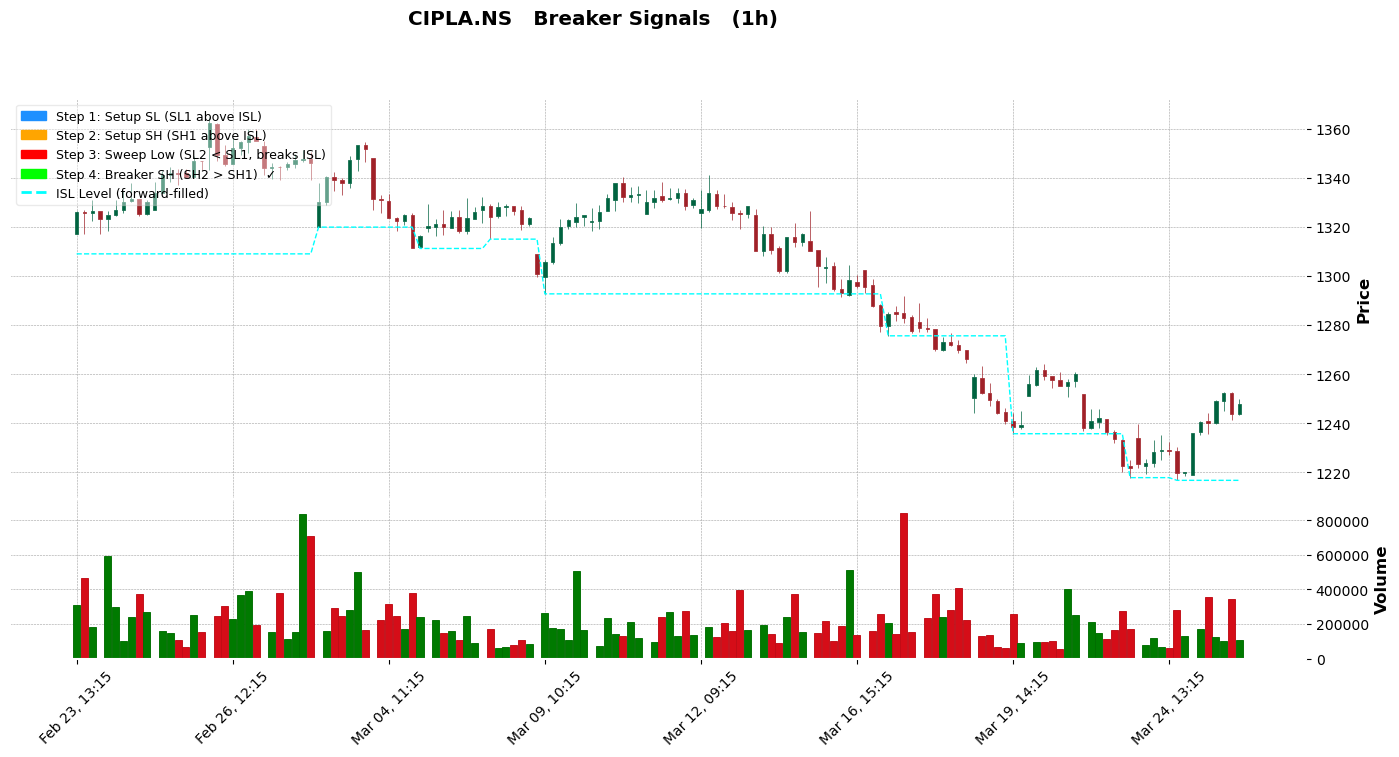

In [19]:

# =============================================================================
#  BREAKER SIGNAL  —  STATIC SINGLE-TICKER
# =============================================================================
#  Exact 4-step sequence (must occur in order):
#    1. Swing Low  (SL1) forms ABOVE the prevailing Intermediate Swing Low (ISL)
#    2. Swing High (SH1) forms next, still above the prevailing ISL
#    3. Swing Low  (SL2) forms LOWER than SL1 AND sweeps through the ISL (ISL Sweep + BOS)
#    4. Swing High (SH2) forms ABOVE SH1                              → BREAKER ✓
# =============================================================================

import pandas as pd
import numpy as np
import yfinance as yf
import mplfinance as mpf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ┌─ CONFIGURATION ─────────────────────────────────────────────────────────┐
TICKER       = 'CIPLA.NS' # Single stock symbol (e.g. 'RELIANCE.NS')
POSITION     = -1              # Slice data to this candle (-1=latest, -144=144 ago)
INTERVAL     = '1h'            # yfinance interval
ATR_PERIOD   = 14              # Period for ATR calculation
BOS_LOOKBACK = 3               # Rolling window of prior swing lows for BOS detection
CHART_BARS   = 150             # Number of recent candles shown in the chart

# Set to a date string like '2026-03-13' to print ISL diagnostics, or '' to skip
DEBUG_ISL_DATE = '2026-03-13'
# └─────────────────────────────────────────────────────────────────────────┘

# ─── Helpers ──────────────────────────────────────────────────────────────────
def strip_tz(ts):
    ts = pd.Timestamp(ts)
    return ts.replace(tzinfo=None)

def strip_tz_idx(idx):
    idx = pd.DatetimeIndex(idx)
    return idx.tz_localize(None) if idx.tzinfo is not None else idx

# ─── Data Download ────────────────────────────────────────────────────────────
fetch_days = max(round(abs(POSITION) / 7 + 45), 60)
raw = yf.Ticker(TICKER).history(period=f'{fetch_days}d', interval=INTERVAL)
if raw is None or raw.empty:
    raise RuntimeError(f'No data returned for {TICKER}')

n   = len(raw)
end = (n + POSITION + 1) if POSITION < 0 else (POSITION + 1)
df  = raw.iloc[:end].copy()

last_candle = strip_tz(df.index[-1]).strftime('%Y-%m-%d %H:%M')
print(f'Loaded {len(df)} candles for {TICKER}  ({INTERVAL})  last candle: {last_candle}')

# ─── ATR ──────────────────────────────────────────────────────────────────────
df['HL'] = df['High'] - df['Low']
df['HC'] = (df['High'] - df['Close'].shift(1)).abs()
df['LC'] = (df['Low']  - df['Close'].shift(1)).abs()
df['TR'] = df[['HL', 'HC', 'LC']].max(axis=1)
df['ATR'] = df['TR'].rolling(ATR_PERIOD).mean()

# ─── Swing Detection ──────────────────────────────────────────────────────────
# SL takes priority when a candle qualifies as both SH and SL simultaneously
_sh_cond = (df['High'] > df['High'].shift(1)) & (df['High'] > df['High'].shift(-1))
_sl_cond = (df['Low']  < df['Low'].shift(1))  & (df['Low']  < df['Low'].shift(-1))
df['Swing'] = np.where(_sl_cond, 'SL', np.where(_sh_cond, 'SH', ''))

sub = df[df['Swing'] != ''].copy()
sl  = sub[sub['Swing'] == 'SL'][['Low']].copy()
sh  = sub[sub['Swing'] == 'SH'][['High']].copy()

# ─── Intermediate Swing Lows (ISL) ────────────────────────────────────────────
# ISL = a swing low that is lower than both its immediately neighbouring swing lows
sl['prev_Low'] = sl['Low'].shift(1)
sl['next_Low'] = sl['Low'].shift(-1)
sl['is_ISL']   = (sl['Low'] < sl['prev_Low']) & (sl['Low'] < sl['next_Low'])
df['ISL_Price'] = np.nan
df.loc[sl[sl['is_ISL']].index, 'ISL_Price'] = sl.loc[sl['is_ISL'], 'Low'].values
df['ISL_Ffill'] = df['ISL_Price'].ffill()

# ─── ISL Diagnostics ──────────────────────────────────────────────────────────
if DEBUG_ISL_DATE:
    target_date = pd.Timestamp(DEBUG_ISL_DATE)
    # Strip tz for comparison
    sl_plain_idx = pd.DatetimeIndex([t.replace(tzinfo=None) for t in sl.index])
    date_mask    = sl_plain_idx.normalize() == target_date.normalize()
    hits_on_date = sl[date_mask]

    print(f'\n{"─"*70}')
    print(f'  ISL DIAGNOSTICS  —  swing lows on {DEBUG_ISL_DATE}  ({TICKER})')
    print(f'{"─"*70}')

    if hits_on_date.empty:
        # Check if the raw candle exists but wasn't detected as a swing low
        df_plain = df.copy()
        df_plain.index = df_plain.index.tz_localize(None) if df_plain.index.tzinfo else df_plain.index
        day_candles = df_plain[df_plain.index.normalize() == target_date]
        if day_candles.empty:
            print(f'  No candle data at all on {DEBUG_ISL_DATE} — date may be outside fetch window.')
        else:
            print(f'  Candles exist on {DEBUG_ISL_DATE} but NONE were detected as swing lows.')
            print(f'  (A swing low requires Low < both immediate candle neighbours.)')
            print(f'\n  Candles on that day:')
            print(day_candles[['Open','High','Low','Close','Swing']].to_string())
    else:
        # Show each swing low on the date with full context
        for raw_ts in hits_on_date.index:
            pos      = sl.index.get_loc(raw_ts)
            ctx_s    = max(0, pos - 3)
            ctx_e    = min(len(sl), pos + 4)
            ctx      = sl.iloc[ctx_s:ctx_e][['Low', 'prev_Low', 'next_Low', 'is_ISL']].copy()
            ctx.index = pd.DatetimeIndex([t.replace(tzinfo=None) for t in ctx.index])

            ts_plain = raw_ts.replace(tzinfo=None)
            row      = ctx.loc[ts_plain] if ts_plain in ctx.index else None

            print(f'\n  Swing low at {ts_plain.strftime("%Y-%m-%d %H:%M")}:')
            if row is not None:
                print(f'    Low        = {row["Low"]:.4f}')
                print(f'    prev_Low   = {row["prev_Low"]:.4f}  (preceding swing low)')
                print(f'    next_Low   = {row["next_Low"]:.4f}  (subsequent swing low)')
                print(f'    Low < prev = {row["Low"] < row["prev_Low"]}')
                print(f'    Low < next = {row["Low"] < row["next_Low"]}')
                print(f'    → is_ISL   = {row["is_ISL"]}')

            print(f'\n  Context (3 swing lows before and after):')
            print(ctx.to_string())

    print(f'{"─"*70}\n')

# ─── Bearish BOS ──────────────────────────────────────────────────────────────
sl_roll = sl['Low'].shift(1).rolling(BOS_LOOKBACK).min().reindex(sub.index)
sub['Bear_BOS'] = (sub['Swing'] == 'SL') & (sub['Low'] < sl_roll)
df['Bear_BOS']  = False
df.loc[sub.index, 'Bear_BOS'] = sub['Bear_BOS'].fillna(False)

# ─── ISL Sweep + BOS ──────────────────────────────────────────────────────────
df['ISL_Sweep_BOS'] = df['Bear_BOS'] & (df['Low'] < df['ISL_Ffill'].shift(1))

# ─── Find All Breaker Setups ──────────────────────────────────────────────────
# Walk the ordered swing sequence looking for the 4-step pattern:
#   SL1 (above ISL) → SH1 (above ISL) → SL2 (< SL1, sweeps ISL) → SH2 (> SH1)

sub_list = list(sub.iterrows())   # list of (index, row) tuples
breakers = []

# All 4 swings must be STRICTLY CONSECUTIVE in the swing sequence:
#   sub_list[i]   = SL1  (above ISL, close filter)
#   sub_list[i+1] = SH1  (above ISL, close > SL1 low)
#   sub_list[i+2] = SL2  (lower than SL1, sweeps ISL)
#   sub_list[i+3] = SH2  (above SH1)  → BREAKER ✓

for i in range(len(sub_list) - 3):
    sl1_idx, sl1_row = sub_list[i]
    sh1_idx, sh1_row = sub_list[i + 1]
    sl2_idx, sl2_row = sub_list[i + 2]
    sh2_idx, sh2_row = sub_list[i + 3]

    # Must be exactly SL → SH → SL → SH
    if (sl1_row['Swing'] != 'SL' or sh1_row['Swing'] != 'SH' or
            sl2_row['Swing'] != 'SL' or sh2_row['Swing'] != 'SH'):
        continue

    sl1_price = float(sl1_row['Low'])
    sh1_price = float(sh1_row['High'])
    sl2_price = float(sl2_row['Low'])
    sh2_price = float(sh2_row['High'])

    # Step 1: SL1 must be ABOVE the prevailing ISL
    isl_at_sl1 = df.loc[sl1_idx, 'ISL_Ffill']
    if pd.isna(isl_at_sl1) or sl1_price <= float(isl_at_sl1):
        continue

    # Step 2: SH1 must also be ABOVE the prevailing ISL
    isl_at_sh1 = df.loc[sh1_idx, 'ISL_Ffill']
    if pd.isna(isl_at_sh1) or sh1_price <= float(isl_at_sh1):
        continue

    # Step 2b: SH1 close must be above SL1 low (wick-spike filter)
    sh1_close = float(df.loc[sh1_idx, 'Close'])
    if sh1_close <= sl1_price:
        continue

    # Step 3: SL2 must be LOWER than SL1 AND sweep through the ISL
    if sl2_price >= sl1_price:
        continue
    isl_at_sweep = df.loc[sl2_idx, 'ISL_Ffill']
    if not df.loc[sl2_idx, 'ISL_Sweep_BOS']:
        continue

    # Step 4: SH2 must be ABOVE SH1
    if sh2_price <= sh1_price:
        continue

    breakers.append({
        'Setup_SL':         strip_tz(sl1_idx).strftime('%Y-%m-%d %H:%M'),
        'Setup_SL_Price':   round(sl1_price, 2),
        'Setup_SH':         strip_tz(sh1_idx).strftime('%Y-%m-%d %H:%M'),
        'Setup_SH_Price':   round(sh1_price, 2),
        'Sweep_Candle':     strip_tz(sl2_idx).strftime('%Y-%m-%d %H:%M'),
        'Sweep_Low':        round(sl2_price, 2),
        'ISL_Swept':        round(float(isl_at_sweep), 2),
        'Breaker_SH':       strip_tz(sh2_idx).strftime('%Y-%m-%d %H:%M'),
        'Breaker_SH_Price': round(sh2_price, 2),
        # raw index references for chart plotting
        '_sl1_idx':         sl1_idx,
        '_sh1_idx':         sh1_idx,
        '_sweep_idx':       sl2_idx,
        '_breaker_sh_idx':  sh2_idx,
        '_isl_level':       float(isl_at_sweep),
    })

# ─── Print Results ────────────────────────────────────────────────────────────
sep = '─' * 80
print(f'\n{sep}')
print(f'  BREAKER SIGNALS   {TICKER}   ({INTERVAL})   POSITION = {POSITION}')
print(sep)

if not breakers:
    print('  No Breaker setups found in the loaded data.\n')
else:
    display_cols = ['Setup_SL', 'Setup_SL_Price', 'Setup_SH', 'Setup_SH_Price',
                    'Sweep_Candle', 'Sweep_Low', 'ISL_Swept',
                    'Breaker_SH', 'Breaker_SH_Price']
    print(pd.DataFrame(breakers)[display_cols].to_string(index=False))
    print(f'\n  Total Breakers found: {len(breakers)}\n')

# ─── Chart ────────────────────────────────────────────────────────────────────
chart_df = df.iloc[-CHART_BARS:][['Open', 'High', 'Low', 'Close', 'Volume']].copy()
chart_df.index = strip_tz_idx(chart_df.index)

# Marker series for the 4 key points
sl1_mark  = pd.Series(np.nan, index=chart_df.index, name='Setup SL')     # blue  ▲ below low
sh1_mark  = pd.Series(np.nan, index=chart_df.index, name='Setup SH')     # orange ▼ above high
sw_mark   = pd.Series(np.nan, index=chart_df.index, name='Sweep Low')    # red   ▼ below low
brk_mark  = pd.Series(np.nan, index=chart_df.index, name='Breaker SH')   # lime  ▲ above high

for b in breakers:
    for raw_ts, series, use_high, nudge in [
        (b['_sl1_idx'],        sl1_mark, False, 0.997),   # below SL1 low
        (b['_sh1_idx'],        sh1_mark, True,  1.003),   # above SH1 high
        (b['_sweep_idx'],      sw_mark,  False, 0.997),   # below sweep low
        (b['_breaker_sh_idx'], brk_mark, True,  1.003),   # above breaker SH high
    ]:
        ts = strip_tz(raw_ts)
        if ts in chart_df.index:
            ref_price      = chart_df.loc[ts, 'High'] if use_high else chart_df.loc[ts, 'Low']
            series.loc[ts] = float(ref_price) * nudge

# ISL forward-fill line
isl_line = df['ISL_Ffill'].iloc[-CHART_BARS:].copy()
isl_line.index = strip_tz_idx(isl_line.index)

apds = []
if sl1_mark.notna().any():
    apds.append(mpf.make_addplot(sl1_mark.values,  type='scatter', markersize=80,  marker='^',
                                 color='dodgerblue', panel=0))
if sh1_mark.notna().any():
    apds.append(mpf.make_addplot(sh1_mark.values,  type='scatter', markersize=80,  marker='v',
                                 color='orange',    panel=0))
if sw_mark.notna().any():
    apds.append(mpf.make_addplot(sw_mark.values,   type='scatter', markersize=80,  marker='v',
                                 color='red',       panel=0))
if brk_mark.notna().any():
    apds.append(mpf.make_addplot(brk_mark.values,  type='scatter', markersize=100, marker='^',
                                 color='lime',      panel=0))
if isl_line.notna().any():
    apds.append(mpf.make_addplot(isl_line.values,  type='line',    color='cyan',   width=1.0,
                                 linestyle='--',    panel=0))

fig, axes = mpf.plot(
    chart_df,
    type='candle',
    style='charles',
    title=f'  {TICKER}   Breaker Signals   ({INTERVAL})',
    addplot=apds,
    volume=True,
    figsize=(18, 8),
    returnfig=True,
)

legend_handles = [
    mpatches.Patch(color='dodgerblue', label='Step 1: Setup SL (SL1 above ISL)'),
    mpatches.Patch(color='orange',     label='Step 2: Setup SH (SH1 above ISL)'),
    mpatches.Patch(color='red',        label='Step 3: Sweep Low (SL2 < SL1, breaks ISL)'),
    mpatches.Patch(color='lime',       label='Step 4: Breaker SH (SH2 > SH1)  ✓'),
    plt.Line2D([0], [0], color='cyan', linestyle='--', label='ISL Level (forward-filled)'),
]
axes[0].legend(handles=legend_handles, loc='upper left', fontsize=9, framealpha=0.4)

plt.tight_layout()
plt.show()
